# Quantity Analysis - Time Series

## Objective
Analyze and forecast **quantity trends** over time using time series analysis techniques.

## Dataset Overview
The dataset contains timestamped records of quantities sold or produced.

## Workflow
1. Load the data
2. Explore time-based patterns
3. Resample and smooth
4. Train a forecasting model
5. Visualize predictions

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load data from Excel file
file_path = 'Raw Data_Predictive Analysis.xlsx'
df = pd.read_excel(file_path)

print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())


Dataset shape: (40563, 9)
Columns: ['OrderDate', 'ParentProductIdNew', 'ParentProductNew', 'ProductCategoryNew', 'ArtistNameNew', 'total_qty_sales', 'Selling Price', 'productListViews', 'productListClicks']


,OrderDate,ParentProductIdNew,ParentProductNew,ProductCategoryNew,ArtistNameNew,total_qty_sales,Selling Price,productListViews,productListClicks
0,2019-01-01,11,Product 11,Category 1,TSSOS,3,399.0,NaN,NaN
1,2019-01-01,114,Product 114,Category 8,TSSA,10,549.0,NaN,NaN
2,2019-01-01,98,Product 98,Category 8,TSSHT,8,499.0,NaN,NaN
3,2019-01-01,97,Product 97,Category 8,TSSF,6,549.0,NaN,NaN
4,2019-01-01,8,Product 8,Category 1,TSSML,6,399.0,NaN,NaN


## Exploratory Data Analysis

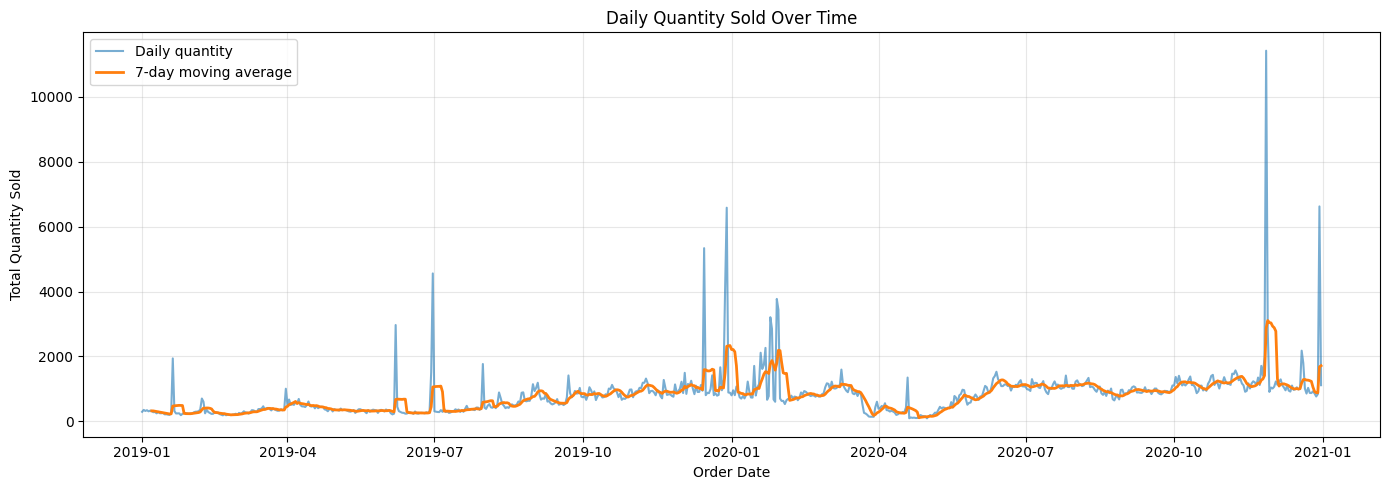

Date range: 2019-01-01 to 2020-12-31
Number of daily observations: 731


In [3]:
# Convert date and quantity columns, then create the daily quantity series
if pd.api.types.is_numeric_dtype(df['OrderDate']):
    df['OrderDate'] = pd.to_datetime(
        df['OrderDate'], unit='D', origin='1899-12-30', errors='coerce'
    )
else:
    df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

df['total_qty_sales'] = pd.to_numeric(df['total_qty_sales'], errors='coerce')
df = df.dropna(subset=['OrderDate', 'total_qty_sales']).sort_values('OrderDate')

daily_quantity = (
    df.set_index('OrderDate')['total_qty_sales']
      .resample('D')
      .sum()
      .asfreq('D')
)

# Fill any missing calendar days with zero sales. The supplied dataset has no gaps.
daily_quantity = daily_quantity.fillna(0)

# Plot raw daily quantity and a 7-day moving average
plt.figure(figsize=(14, 5))
plt.plot(daily_quantity.index, daily_quantity.values, label='Daily quantity', alpha=0.6)
plt.plot(
    daily_quantity.index,
    daily_quantity.rolling(7).mean(),
    label='7-day moving average',
    linewidth=2
)
plt.title('Daily Quantity Sold Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Quantity Sold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Date range:', daily_quantity.index.min().date(), 'to', daily_quantity.index.max().date())
print('Number of daily observations:', len(daily_quantity))


## Decomposition

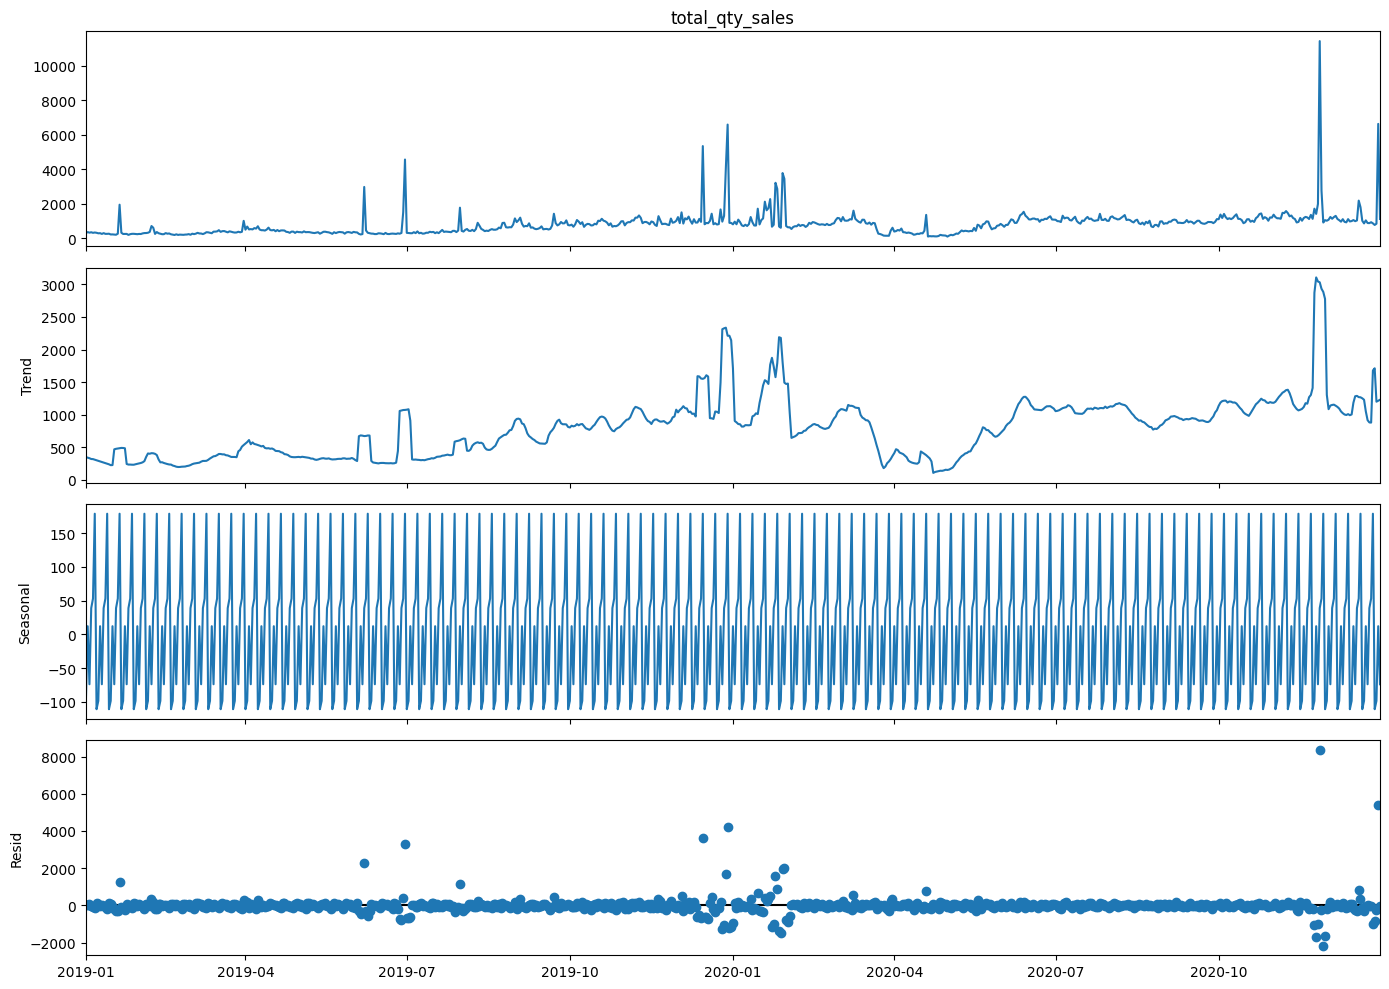

In [4]:
# Set date as index
ts = daily_quantity.copy()
ts.index.name = 'OrderDate'

# Decompose the daily series using a weekly (7-day) seasonal period
decomposition = seasonal_decompose(ts, model='additive', period=7, extrapolate_trend='freq')

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## Modeling with ARIMA

In [5]:
# Train-test split: use the first 80% for training and the last 20% for testing
train_size = int(len(ts) * 0.80)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print('Training observations:', len(train))
print('Testing observations:', len(test))

# Fit a baseline ARIMA model
model = ARIMA(
    train,
    order=(2, 1, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit()
print(model_fit.summary())

# Forecast the complete test period
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index


Training observations: 584
Testing observations: 147
                               SARIMAX Results                                
Dep. Variable:        total_qty_sales   No. Observations:                  584
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -4384.592
Date:                Thu, 24 Sep 2026   AIC                           8779.184
Time:                        17:09:26   BIC                           8800.999
Sample:                    01-01-2019   HQIC                          8787.689
                         - 08-06-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0820      0.266      0.308      0.758      -0.440       0.604
ar.L2         -0.0782      0.095     -0.824      0.410      -0.264       0.108

## Evaluation and Visualization

RMSE: 1000.85


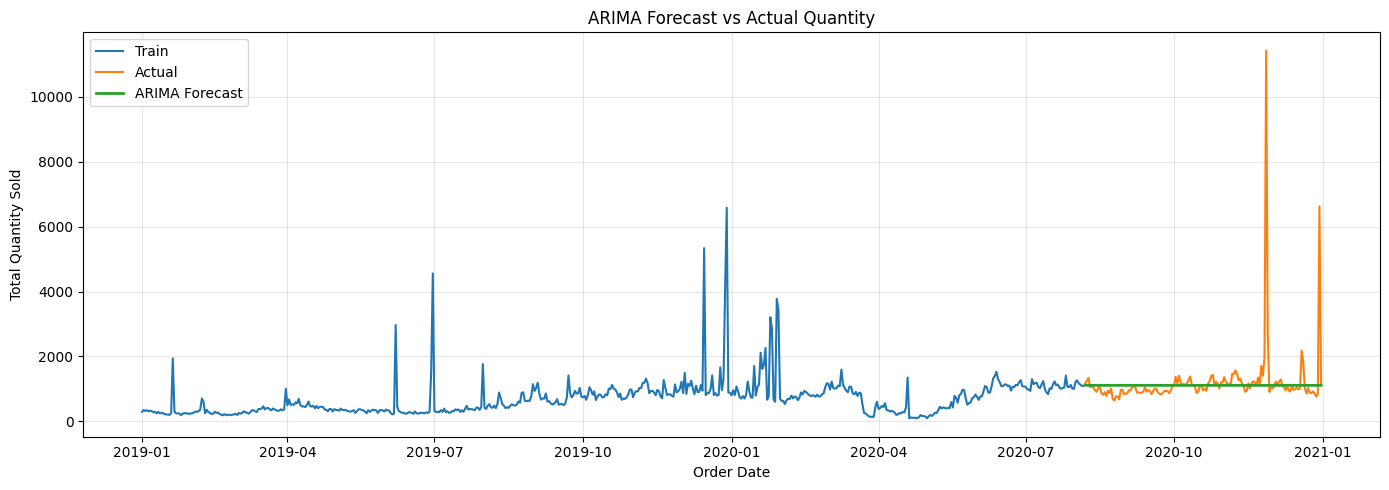

In [6]:
# Evaluation
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'RMSE: {rmse:.2f}')

# Plot forecast vs actual
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Actual')
plt.plot(forecast.index, forecast.values, label='ARIMA Forecast', linewidth=2)
plt.title('ARIMA Forecast vs Actual Quantity')
plt.xlabel('Order Date')
plt.ylabel('Total Quantity Sold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Conclusion
- Time series modeling was applied to understand and forecast quantity trends.
- ARIMA provided a simple baseline.
- For improvement, consider SARIMA, Prophet, or LSTM for long-term patterns.